# 🍽️ Recipe Recommendation System
### Content-Based Filtering using TF-IDF + Cosine Similarity
This notebook builds a user-facing recipe recommender that takes:
- Ingredients the user has on hand
- Priority ingredients to heavily boost (e.g. the protein)
- Max prep time
- Max cook time
- Cuisine preference
- Minimum ingredient match threshold

And returns the top matching recipes ranked by relevance.

## Cell 1 — Install & Import Libraries

In [1]:
# Run this cell first to install any missing libraries
!pip install pandas scikit-learn numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Show full URLs in output tables without truncation
pd.set_option('display.max_colwidth', None)

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## Cell 2 — Load & Preview the Dataset

In [3]:
# Load dataset — make sure allrecipes_dataset.csv is in the same folder as this notebook
df = pd.read_csv('allrecipes_dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'Cuisines found: {sorted(df["cuisine"].unique())}')
df.head()

Dataset shape: (1746, 9)
Cuisines found: ['Brazilian', 'Cajun_Creole', 'Chinese', 'Cuban', 'French', 'German', 'Greek', 'Indian', 'Italian', 'Japanese', 'Mediterranean', 'Mexican', 'Peruvian', 'Soul_Food', 'Southern', 'Tex_Mex', 'Thai', 'Vietnamese']


,title,cuisine,ingredients,prep_time_min,cook_time_min,total_time_min,rating,servings,url
0,Mexican Rice,Mexican,3 tablespoons vegetable oil | 1 cup uncooked long-grain rice | 1/4 cup chopped onion | 1 teaspoon garlic salt | 1/2 teaspoon ground cumin | 2 cups chicken broth | 1/2 cup tomato sauce,5.0,30.0,35.0,4.7,4 servings,https://www.allrecipes.com/recipe/27072/mexican-rice-ii/
1,Rich Mexican Corn,Mexican,"1 (8 ounce) package cream cheese | 1/2 cup butter | 1/2 cup milk | 1 (16 ounce) package frozen corn | 8 fresh jalapeno peppers, diced | 1 red bell pepper, diced",15.0,45.0,60.0,4.6,8 servings,https://www.allrecipes.com/recipe/66657/rich-mexican-corn/
2,Quick and Easy Mexican Chicken,Mexican,"cooking spray | 4 skinless, boneless chicken breasts | 1 clove garlic, minced | 1 pinch salt | 1 pinch ground black pepper | 1 pinch ground cumin | 1 cup salsa | 1 cup shredded Cheddar cheese",15.0,25.0,40.0,4.5,4 servings,https://www.allrecipes.com/recipe/8597/quick-and-easy-mexican-chicken/
3,Simple Mexican Rice,Mexican,"2 tablespoons vegetable oil | 1 onion, chopped | 1 teaspoon minced garlic | 1 teaspoon chili powder | 1 tablespoon ground cumin | 1 cup uncooked short-grain white rice | 1 3/4 cups chicken broth | 1/4 cup tomato paste",10.0,40.0,50.0,4.2,5 servings,https://www.allrecipes.com/recipe/88095/simple-mexican-rice/
4,Mexican Pizza,Mexican,"1/2 pound ground beef | 1 medium onion, diced | 1 clove garlic, minced | 1 tablespoon chili powder | 1 teaspoon ground cumin | 1/2 teaspoon paprika | 1/2 teaspoon salt | 1/2 teaspoon black pepper | 1 (16 ounce) can refried beans | 4 (10 inch) flour tortillas | 1/2 cup salsa | 1 cup shredded Cheddar cheese | 1 cup shredded Monterey Jack cheese | 2 green onions, chopped | 2 roma (plum) tomatoes, diced | 1/4 cup thinly sliced jalapeno pepper | 1/4 cup sour cream",20.0,25.0,45.0,4.7,8 servings,https://www.allrecipes.com/recipe/53075/jimmys-mexican-pizza/


## Cell 3 — Clean & Preprocess the Data

In [4]:
# ── Remove duplicates caused by scraper pause/resume ─────────────────────────
# URL is the unique identifier for each recipe
before = len(df)
df = df.drop_duplicates(subset=['url'])
after = len(df)
print(f'🧹 Removed {before - after} duplicate recipes ({after} remaining)')

# ── Drop rows missing critical fields ─────────────────────────────────────────
df = df.dropna(subset=['ingredients', 'title'])

# ── Convert time and rating columns to numbers ────────────────────────────────
df['prep_time_min']  = pd.to_numeric(df['prep_time_min'],  errors='coerce')
df['cook_time_min']  = pd.to_numeric(df['cook_time_min'],  errors='coerce')
df['total_time_min'] = pd.to_numeric(df['total_time_min'], errors='coerce')
df['rating']         = pd.to_numeric(df['rating'],         errors='coerce')

# ── Fill missing values with median so recipes still appear in results ────────
df['prep_time_min'].fillna(df['prep_time_min'].median(),   inplace=True)
df['cook_time_min'].fillna(df['cook_time_min'].median(),   inplace=True)
df['total_time_min'].fillna(df['total_time_min'].median(), inplace=True)
df['rating'].fillna(df['rating'].median(),                 inplace=True)

# ── Normalize cuisine names for consistent matching ───────────────────────────
df['cuisine'] = df['cuisine'].str.strip().str.lower()

# ── Clean ingredients into a single lowercase string for TF-IDF ──────────────
df['ingredients_clean'] = (
    df['ingredients']
    .str.lower()
    .str.replace(r'[^a-z\s|]', '', regex=True)
    .str.replace('|', ' ', regex=False)
)

# Reset index so the cosine similarity matrix stays aligned with the dataframe
df = df.reset_index(drop=True)

print(f'✅ Cleaned dataset: {len(df)} recipes across {df["cuisine"].nunique()} cuisines')
print(f'Time range — prep: {df["prep_time_min"].min():.0f}–{df["prep_time_min"].max():.0f} min | '
      f'cook: {df["cook_time_min"].min():.0f}–{df["cook_time_min"].max():.0f} min')

🧹 Removed 0 duplicate recipes (1746 remaining)
✅ Cleaned dataset: 1746 recipes across 18 cuisines
Time range — prep: 1–510 min | cook: 1–1500 min


## Cell 4 — Build the TF-IDF Matrix
TF-IDF weighs ingredients by how unique they are across all recipes.
Common ingredients (salt, water) get lower weight. Unique ones (miso, plantain) get higher weight.
This is the foundation of our content-based filtering approach.

In [5]:
# Build TF-IDF matrix on ingredient text
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # captures single words AND pairs e.g. 'black beans', 'olive oil'
    min_df=2,             # ignore ingredients appearing in fewer than 2 recipes
    max_df=0.95,          # ignore ingredients in more than 95% of recipes (too generic)
    stop_words='english'  # remove generic English words
)

tfidf_matrix = tfidf.fit_transform(df['ingredients_clean'])

print(f'✅ TF-IDF matrix: {tfidf_matrix.shape[0]} recipes × {tfidf_matrix.shape[1]} ingredient terms')

✅ TF-IDF matrix: 1746 recipes × 6175 ingredient terms


## Cell 5 — Build the Recommendation Function
**How scoring works:**
- User inputs are vectorized using the same TF-IDF vocabulary
- Priority ingredients are repeated in the input vector to boost their weight
- Cosine similarity measures how closely each recipe matches the user's ingredients
- Final relevance score = 80% ingredient match + 20% rating
- Recipes below the minimum match threshold are filtered out entirely

In [6]:
def recommend_recipes(
    user_ingredients,
    max_prep_time=None,
    max_cook_time=None,
    cuisine=None,
    top_n=5,
    priority_ingredients=None,  # ingredients to heavily boost (e.g. your protein)
    priority_boost=5.0,         # how many times to repeat priority ingredients
    min_match=5.0               # minimum ingredient match % — filters out irrelevant recipes
):
    """
    Recommend recipes based on user inputs.

    Parameters:
    -----------
    user_ingredients     : str   Comma-separated ingredients the user has.
                                 Example: 'chicken, garlic, lemon, olive oil'
    max_prep_time        : int   Max prep time in minutes. None = no limit.
    max_cook_time        : int   Max cook time in minutes. None = no limit.
    cuisine              : str   e.g. 'italian', 'mexican'. None = any cuisine.
    top_n                : int   Number of results to return.
    priority_ingredients : str   Comma-separated ingredients to heavily boost.
                                 These get repeated priority_boost times in the
                                 input vector so they dominate the similarity score.
                                 Example: 'chicken' or 'steak, beef'
    priority_boost       : float How many times to repeat priority ingredients.
                                 Higher = stronger boost. Default is 5.
    min_match            : float Minimum ingredient match % to appear in results.
                                 Recipes scoring below this are excluded entirely.
                                 Default is 5.0 (5%).
    """

    # ── Step 1: Hard filters — time and cuisine ───────────────────────────────
    filtered = df.copy()

    if max_prep_time is not None:
        filtered = filtered[filtered['prep_time_min'] <= max_prep_time]

    if max_cook_time is not None:
        filtered = filtered[filtered['cook_time_min'] <= max_cook_time]

    if cuisine is not None:
        filtered = filtered[filtered['cuisine'] == cuisine.strip().lower()]

    if filtered.empty:
        print('⚠️  No recipes match your time/cuisine filters. Try relaxing your constraints.')
        return None

    # ── Step 2: Build boosted user input vector ───────────────────────────────
    # Parse all ingredients and identify which ones are priority
    all_ingredients = [i.strip().lower() for i in user_ingredients.split(',')]

    if priority_ingredients:
        priority_list = [p.strip().lower() for p in priority_ingredients.split(',')]
        print(f'🔺 Boosting priority ingredients x{int(priority_boost)}: {priority_list}')
    else:
        priority_list = []

    # Repeat priority ingredients to increase their TF-IDF weight
    boosted_parts = []
    for ingredient in all_ingredients:
        if ingredient in priority_list:
            boosted_parts.extend([ingredient] * int(priority_boost))
        else:
            boosted_parts.append(ingredient)

    user_vector = tfidf.transform([' '.join(boosted_parts)])

    # ── Step 3: Cosine similarity against filtered recipes ────────────────────
    filtered_indices = filtered.index.tolist()
    filtered_tfidf   = tfidf_matrix[filtered_indices]
    similarities     = cosine_similarity(user_vector, filtered_tfidf).flatten()

    # ── Step 4: Apply minimum match threshold ────────────────────────────────
    # Convert similarity scores to percentages and filter out low matches
    # This prevents high-rated but irrelevant recipes from appearing in results
    similarity_pct = similarities * 100
    above_threshold = similarity_pct >= min_match

    if not any(above_threshold):
        print(f'⚠️  No recipes scored above the {min_match}% match threshold.')
        print('    Try lowering min_match or adding more ingredients.')
        return None

    # Filter to only recipes above the threshold
    filtered       = filtered.iloc[above_threshold]
    similarities   = similarities[above_threshold]
    similarity_pct = similarity_pct[above_threshold]

    # ── Step 5: Normalize ratings (0–1 scale) ────────────────────────────────
    max_rating   = df['rating'].max()
    min_rating   = df['rating'].min()
    rating_range = max_rating - min_rating if max_rating != min_rating else 1
    norm_ratings = (filtered['rating'].values - min_rating) / rating_range

    # ── Step 6: Weighted relevance score ─────────────────────────────────────
    # Ingredient match drives recommendations (80%), rating is tiebreaker (20%)
    INGREDIENT_WEIGHT = 0.80
    RATING_WEIGHT     = 0.20
    relevance_scores  = INGREDIENT_WEIGHT * similarities + RATING_WEIGHT * norm_ratings

    # ── Step 7: Build and return results dataframe ────────────────────────────
    results = filtered.copy()
    results['ingredient_match'] = similarity_pct.round(1)
    results['relevance_score']  = (relevance_scores * 100).round(1)

    results = (
        results
        .sort_values('relevance_score', ascending=False)
        .head(top_n)
    )

    display_cols = [
        'title', 'cuisine', 'prep_time_min', 'cook_time_min',
        'rating', 'ingredient_match', 'relevance_score', 'url'
    ]
    return results[display_cols].reset_index(drop=True)

print('✅ Recommender function ready!')

✅ Recommender function ready!


## Cell 6 — Try It Out!
Edit the inputs below and run the cell to get personalized recipe recommendations.

**Tips:**
- Set `PRIORITY_INGREDIENTS` to your protein or most important ingredient
- Set `CUISINE` to `None` to search across all cuisines
- Lower `MIN_MATCH` if you're getting no results; raise it to filter out weak matches
- Increase `PRIORITY_BOOST` (e.g. 8 or 10) if your key ingredient still isn't dominating

In [7]:
# ── ✏️  EDIT THESE INPUTS ─────────────────────────────────────────────────────

MY_INGREDIENTS       = 'beans, flour, water, salt, pasta, pepper, canned tomatoes, chicken, milk, eggs, cheese, onion, garlic, oil'
PRIORITY_INGREDIENTS = None   # set to None for no boost
MAX_PREP_TIME        = 15          # minutes — set to None for no limit
MAX_COOK_TIME        = 30         # minutes — set to None for no limit
CUISINE              = None        # e.g. 'italian', 'mexican', 'thai' — None = any
HOW_MANY             = 15          # number of results to show
MIN_MATCH            = 5.0         # minimum ingredient match % (0 = no filter)

# ── Run the recommender ───────────────────────────────────────────────────────
results = recommend_recipes(
    user_ingredients     = MY_INGREDIENTS,
    max_prep_time        = MAX_PREP_TIME,
    max_cook_time        = MAX_COOK_TIME,
    cuisine              = CUISINE,
    top_n                = HOW_MANY,
    priority_ingredients = PRIORITY_INGREDIENTS,
    min_match            = MIN_MATCH
)

if results is not None:
    print(f'\n🍽️  Top {HOW_MANY} recipes for your ingredients:')
    print(f'   Ingredients : {MY_INGREDIENTS}')
    print(f'   Priority    : {PRIORITY_INGREDIENTS}')
    print(f'   Max prep    : {MAX_PREP_TIME} min | Max cook: {MAX_COOK_TIME} min')
    print(f'   Cuisine     : {CUISINE or "Any"} | Min match: {MIN_MATCH}%')
    print()
    display(results)


🍽️  Top 15 recipes for your ingredients:
   Ingredients : beans, flour, water, salt, pasta, pepper, canned tomatoes, chicken, milk, eggs, cheese, onion, garlic, oil
   Priority    : None
   Max prep    : 15 min | Max cook: 30 min
   Cuisine     : Any | Min match: 5.0%



,title,cuisine,prep_time_min,cook_time_min,rating,ingredient_match,relevance_score,url
0,Fluffy French Toast,french,10.0,20.0,4.7,18.6,32.9,https://www.allrecipes.com/recipe/16895/fluffy-french-toast/
1,Jeera Rice (Cumin Rice),indian,5.0,15.0,4.6,16.7,30.7,https://www.allrecipes.com/recipe/14130/jeera-cumin-rice/
2,Beer Batter Fish Fillets,french,5.0,20.0,4.3,16.4,28.4,https://www.allrecipes.com/recipe/12734/beer-batter-fish-fillets/
3,French Toast Waffles,french,5.0,20.0,4.1,16.5,27.2,https://www.allrecipes.com/recipe/18053/french-toast-waffles/
4,Chile Verde Quiche,tex_mex,15.0,30.0,4.6,11.4,26.5,https://www.allrecipes.com/recipe/275825/chile-verde-quiche/
5,Chicken Nachos with Refried Beans,tex_mex,10.0,10.0,4.8,9.8,26.5,https://www.allrecipes.com/recipe/273239/chicken-nachos-with-refried-beans/
6,Italian Sausage and Gnocchi Soup,italian,10.0,30.0,4.8,9.6,26.4,https://www.allrecipes.com/recipe/245092/italian-sausage-and-gnocchi-soup/
7,Cherry Tomato Pasta Sauce,italian,15.0,10.0,4.8,9.0,25.9,https://www.allrecipes.com/recipe/237321/cherry-tomato-sauce-with-penne/
8,Barbarella's German Pancakes,german,5.0,10.0,4.4,12.4,25.9,https://www.allrecipes.com/recipe/40071/barbarellas-german-pancakes/
9,Brazilian Cheese Bread (Pao de Queijo),brazilian,10.0,20.0,4.3,13.2,25.9,https://www.allrecipes.com/recipe/98554/brazilian-cheese-bread-pao-de-queijo/


## Cell 7 — Explore Your Dataset
Useful visualizations for your poster presentation.

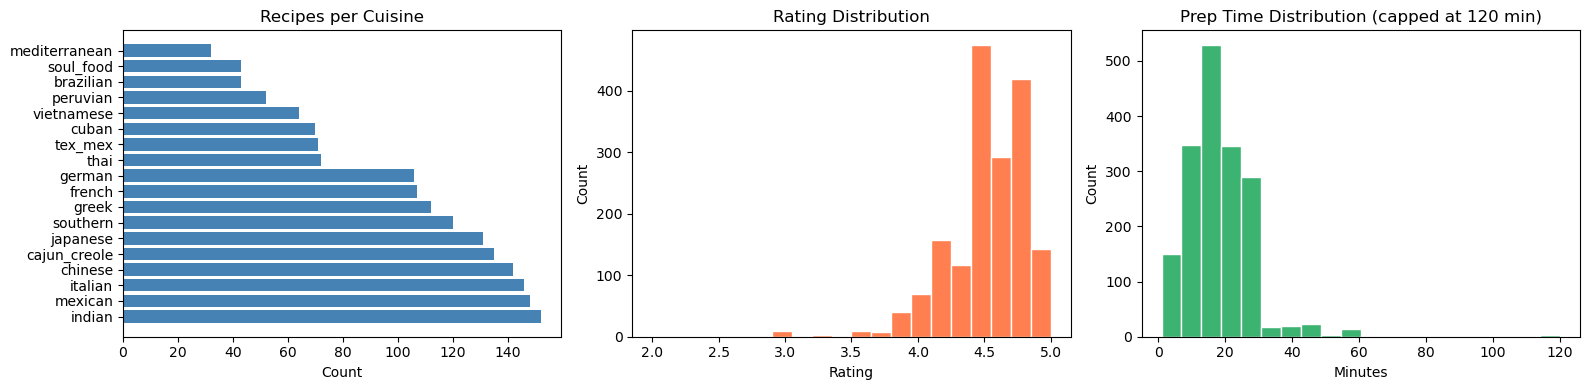

Total recipes: 1746
       prep_time_min  cook_time_min  rating
count         1746.0         1746.0  1746.0
mean            18.3           60.7     4.5
std             17.6          103.9     0.3
min              1.0            1.0     2.0
25%             10.0           20.0     4.4
50%             15.0           30.0     4.5
75%             20.0           50.0     4.7
max            510.0         1500.0     5.0


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Recipes per cuisine
cuisine_counts = df['cuisine'].value_counts()
axes[0].barh(cuisine_counts.index, cuisine_counts.values, color='steelblue')
axes[0].set_title('Recipes per Cuisine')
axes[0].set_xlabel('Count')

# Rating distribution
axes[1].hist(df['rating'].dropna(), bins=20, color='coral', edgecolor='white')
axes[1].set_title('Rating Distribution')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')

# Prep time distribution (capped at 120 min for readability)
axes[2].hist(df['prep_time_min'].clip(upper=120), bins=20, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Prep Time Distribution (capped at 120 min)')
axes[2].set_xlabel('Minutes')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Total recipes: {len(df)}')
print(df[['prep_time_min', 'cook_time_min', 'rating']].describe().round(1))

## Cell 8 — Evaluate: Precision Score
Precision measures what proportion of recommended recipes are actually relevant.
A recipe is considered relevant if its ingredient match score is above the threshold.

In [9]:
def evaluate_precision(results, user_ingredients, priority_ingredients=None, match_threshold=30.0, min_additional=2):
    """
    Combined evaluation using Option A + Option C.

    A recipe is considered truly relevant if:
      1. Its ingredient_match score is >= match_threshold (Option A)
      2. It contains the priority ingredient (Option C - rule 1)
      3. It contains at least min_additional other user ingredients (Option C - rule 2)

    Parameters:
    -----------
    results              : DataFrame from recommend_recipes()
    user_ingredients     : str   same input you passed to the recommender
    priority_ingredients : str   same priority input you passed to the recommender
    match_threshold      : float minimum match % to count as relevant (default 30%)
    min_additional       : int   minimum additional ingredients beyond priority (default 2)
    """
    if results is None or results.empty:
        print('No results to evaluate.')
        return 0.0

    all_ingredients = [i.strip().lower() for i in user_ingredients.split(',')]
    priority_list   = [p.strip().lower() for p in priority_ingredients.split(',')] \
        if priority_ingredients else []
    
    other_ingredients = [i for i in all_ingredients if i not in priority_list]

    relevant_count = 0

    print(f'\n📊 Evaluating {len(results)} recommendations:')
    print(f'   Threshold  : {match_threshold}% match score')
    print(f'   Must contain priority ingredient(s): {priority_list}')
    print(f'   Must contain at least {min_additional} other ingredients from your list')
    print()

    for _, row in results.iterrows():
        # Look up the full ingredients from the main df using the recipe URL
        recipe_ingredients = df.loc[df['url'] == row['url'], 'ingredients_clean'].values[0]

        # Rule 1 (Option A): match score must be above threshold
        passes_threshold = row['ingredient_match'] >= match_threshold

        # Rule 2 (Option C-1): must contain priority ingredient
        contains_priority = all(p in recipe_ingredients for p in priority_list) \
                            if priority_list else True

        # Rule 3 (Option C-2): must contain at least min_additional other ingredients
        additional_matches = sum(1 for i in other_ingredients if i in recipe_ingredients)
        passes_additional  = additional_matches >= min_additional

        is_relevant = passes_threshold and contains_priority and passes_additional

        status = '✅' if is_relevant else '❌'
        print(f'  {status} {row["title"][:45]:<45} | '
              f'match: {row["ingredient_match"]}% | '
              f'priority: {"✓" if contains_priority else "✗"} | '
              f'other matches: {additional_matches}')

        if is_relevant:
            relevant_count += 1

    precision = relevant_count / len(results)
    print(f'\n🎯 Precision: {precision:.2f} ({relevant_count}/{len(results)} recipes truly relevant)')
    return precision

# Re-run recommender and evaluate
results = recommend_recipes(
    user_ingredients     = MY_INGREDIENTS,
    max_prep_time        = MAX_PREP_TIME,
    max_cook_time        = MAX_COOK_TIME,
    cuisine              = CUISINE,
    top_n                = HOW_MANY,
    priority_ingredients = PRIORITY_INGREDIENTS,
    min_match            = MIN_MATCH
)

evaluate_precision(
    results              = results,
    user_ingredients     = MY_INGREDIENTS,
    priority_ingredients = PRIORITY_INGREDIENTS,
    match_threshold      = 11.50,   # Option A: must score 30%+ to be relevant
    min_additional       = 2       # Option C: must contain 2+ other ingredients
)


📊 Evaluating 15 recommendations:
   Threshold  : 11.5% match score
   Must contain priority ingredient(s): []
   Must contain at least 2 other ingredients from your list

  ✅ Fluffy French Toast                           | match: 18.6% | priority: ✓ | other matches: 4
  ✅ Jeera Rice (Cumin Rice)                       | match: 16.7% | priority: ✓ | other matches: 3
  ✅ Beer Batter Fish Fillets                      | match: 16.4% | priority: ✓ | other matches: 5
  ✅ French Toast Waffles                          | match: 16.5% | priority: ✓ | other matches: 2
  ❌ Chile Verde Quiche                            | match: 11.4% | priority: ✓ | other matches: 6
  ❌ Chicken Nachos with Refried Beans             | match: 9.8% | priority: ✓ | other matches: 4
  ❌ Italian Sausage and Gnocchi Soup              | match: 9.6% | priority: ✓ | other matches: 7
  ❌ Cherry Tomato Pasta Sauce                     | match: 9.0% | priority: ✓ | other matches: 7
  ✅ Barbarella's German Pancakes               

0.4